## Predictive Modelling — Academic Stress Level Classification Among IIT Students 

## 1. Setup and Data Loading

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


In [38]:
df=pd.read_csv('model_ready.csv')


We will drop The overall stress column as Stress_level is the target column and if we use overall_stress then we can directly get stress_level column without seeing other data which leads to data leakage so we dropped this column

In [39]:
df.drop(columns=['Overall_Stress'],inplace=True)


In [40]:
print("Shape=",df.shape)
print("Columns =",df.columns)
print("Data Types:\n",df.dtypes)

Shape= (102, 10)
Columns = Index(['Sleep_Hours', 'Screen_Time', 'Exercise_Freq', 'Diet_Quality',
       'Study_Hours', 'CGPA', 'GAD_Nervous', 'GAD_Irritable', 'GAD_Score',
       'Stress_Level'],
      dtype='object')
Data Types:
 Sleep_Hours        int64
Screen_Time        int64
Exercise_Freq      int64
Diet_Quality       int64
Study_Hours        int64
CGPA               int64
GAD_Nervous        int64
GAD_Irritable      int64
GAD_Score        float64
Stress_Level      object
dtype: object


In [41]:
df['Stress_Level'].value_counts()


Stress_Level
High      43
Medium    34
Low       25
Name: count, dtype: int64

## 2. Feature and Target Definition

In [42]:
X=df[['Sleep_Hours','Screen_Time','Exercise_Freq','Diet_Quality','Study_Hours','CGPA','GAD_Nervous','GAD_Irritable','GAD_Score']]
Y=df['Stress_Level']

In [43]:
print("Features (X) Shape:", X.shape)
print("Target variable shape:",Y.shape)

Features (X) Shape: (102, 9)
Target variable shape: (102,)


## 3. Train Test Split

In [44]:
# Train-test split
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42,stratify=Y)

In [45]:
print("Train size:",X_train.shape)
print("Test size:",X_test.shape)

print("\nClass distribution in train set:\n", Y_train.value_counts())
print("\nClass distribution in test set:\n", Y_test.value_counts())

Train size: (81, 9)
Test size: (21, 9)

Class distribution in train set:
 Stress_Level
High      34
Medium    27
Low       20
Name: count, dtype: int64

Class distribution in test set:
 Stress_Level
High      9
Medium    7
Low       5
Name: count, dtype: int64


## 4. Model Building and Evaluation

In [46]:
# Lets calculate the base accuacy by predicting the majority class
from sklearn.metrics import accuracy_score
baseline_acc=Y_test.value_counts().max()/len(Y_test)
print(f"Baseline Accuracy: {baseline_acc * 100:.2f}%")

Baseline Accuracy: 42.86%


"Logistic Regression is a linear classification algorithm that estimates the probability of each class. It works well as a baseline classifier and is interpretable — we can examine coefficients to understand feature influence. We use class_weight='balanced' to handle the slight class imbalance in our dataset."

In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)
model=LogisticRegression(max_iter=1000,class_weight='balanced')
model.fit(X_train,Y_train)
Y_pred=model.predict(X_test)
print("Classification Report:\n",classification_report(Y_test,Y_pred))
print("Confusion Matrix:\n",confusion_matrix(Y_test,Y_pred))
print("Accuracy:",accuracy_score(Y_test,Y_pred))

Classification Report:
               precision    recall  f1-score   support

        High       0.78      0.78      0.78         9
         Low       0.62      1.00      0.77         5
      Medium       0.75      0.43      0.55         7

    accuracy                           0.71        21
   macro avg       0.72      0.74      0.70        21
weighted avg       0.73      0.71      0.70        21

Confusion Matrix:
 [[7 1 1]
 [0 5 0]
 [2 2 3]]
Accuracy: 0.7142857142857143


Logistic Regression performs well in classifying extreme stress levels due to its linear decision boundaries. However, it struggles with medium stress levels, which lie in overlapping regions of the feature space. This highlights the limitation of linear models in capturing complex behavioral patterns.

A Decision Tree classifies by learning simple threshold-based rules from features — for example 'if GAD_Score > 3 and Sleep_Hours < 2, predict High stress'. It is well suited for ordinal encoded data like ours. max_depth=4 prevents overfitting on our small dataset of 102 rows.

In [48]:
from sklearn.tree import DecisionTreeClassifier
dt_model=DecisionTreeClassifier(max_depth=4,class_weight='balanced',random_state=42,splitter='best')
dt_model.fit(X_train,Y_train)
Y_dt_pred=dt_model.predict(X_test)
print("Decision Tree Classification Report:\n",classification_report(Y_test,Y_dt_pred))
print("Decision Tree Confusion Matrix:\n",confusion_matrix(Y_test,Y_dt_pred))
print("Decision Tree Accuracy:",accuracy_score(Y_test,Y_dt_pred))

Decision Tree Classification Report:
               precision    recall  f1-score   support

        High       0.80      0.44      0.57         9
         Low       1.00      0.60      0.75         5
      Medium       0.46      0.86      0.60         7

    accuracy                           0.62        21
   macro avg       0.75      0.63      0.64        21
weighted avg       0.73      0.62      0.62        21

Decision Tree Confusion Matrix:
 [[4 0 5]
 [0 3 2]
 [1 0 6]]
Decision Tree Accuracy: 0.6190476190476191


Random Forest builds multiple decision trees on random subsets of data and averages their predictions. It generally outperforms a single tree — however with only 81 training rows each individual tree sees very limited data, which can limit its advantage over a single well-tuned tree.

In [49]:
from sklearn.ensemble import RandomForestClassifier
rf_model=RandomForestClassifier(n_estimators=100,class_weight='balanced',random_state=42)
rf_model.fit(X_train,Y_train)
Y_rf_pred=rf_model.predict(X_test)
print("Random Forest Classification Report:\n",classification_report(Y_test,Y_rf_pred))
print("Random Forest Confusion Matrix:\n",confusion_matrix(Y_test,Y_rf_pred))
print("Random Forest Accuracy:",accuracy_score(Y_test,Y_rf_pred))

Random Forest Classification Report:
               precision    recall  f1-score   support

        High       0.73      0.89      0.80         9
         Low       0.60      0.60      0.60         5
      Medium       0.60      0.43      0.50         7

    accuracy                           0.67        21
   macro avg       0.64      0.64      0.63        21
weighted avg       0.65      0.67      0.65        21

Random Forest Confusion Matrix:
 [[8 1 0]
 [0 3 2]
 [3 1 3]]
Random Forest Accuracy: 0.6666666666666666


Random Forest improves the detection of high stress cases due to its ability to capture non-linear patterns, but overall performance decreases, likely due to limited dataset size. Both models struggle with medium stress classification, indicating overlapping feature patterns.

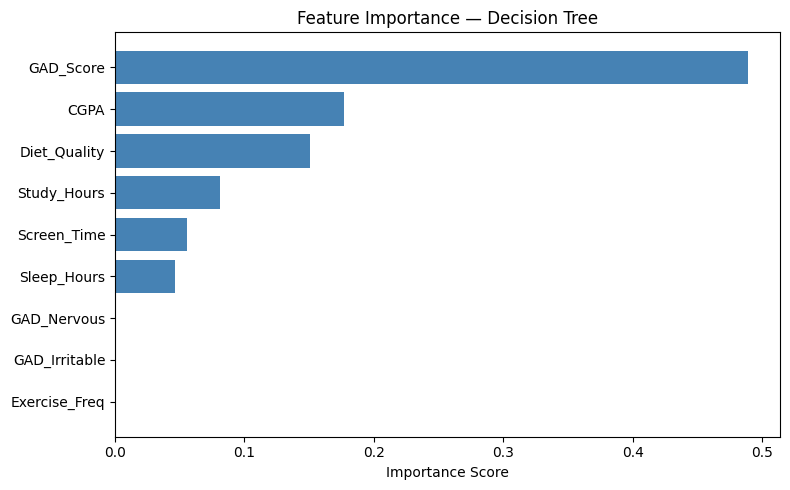

In [50]:
importance_df = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(importance_df['Feature'], importance_df['Importance'],
         color='steelblue')
plt.xlabel('Importance Score')
plt.title('Feature Importance — Decision Tree')
plt.tight_layout()
plt.show()

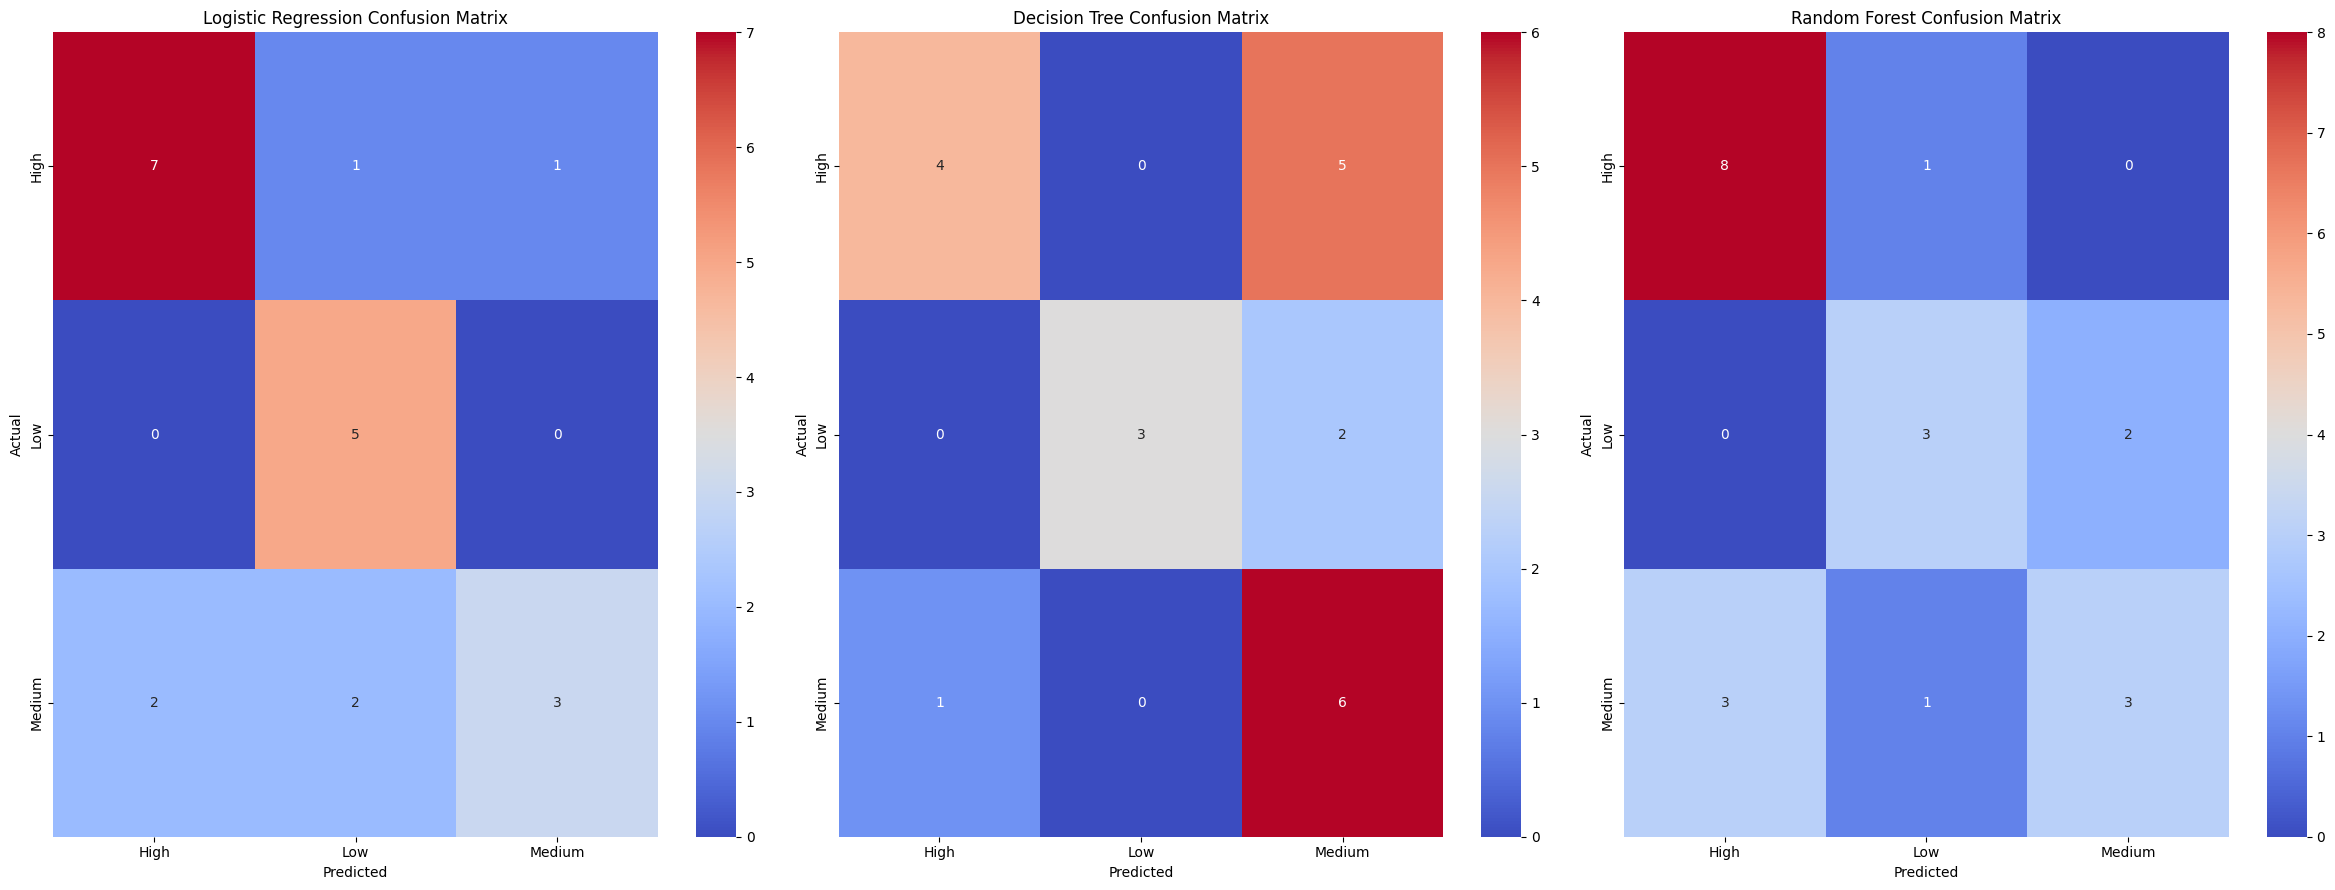

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(24, 9))
for ax, model_name, y_pred in zip(axes, ['Logistic Regression', 'Decision Tree', 'Random Forest'], [Y_pred, Y_dt_pred, Y_rf_pred]):
    sns.heatmap(confusion_matrix(Y_test, y_pred), annot=True, fmt='d', ax=ax, cmap='coolwarm',xticklabels=['High', 'Low', 'Medium'],yticklabels=['High', 'Low', 'Medium'])
    ax.set_title(f'{model_name} Confusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

In [52]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [f'{accuracy_score(Y_test,Y_pred)*100:.2f}%',
                 f'{accuracy_score(Y_test,Y_dt_pred)*100:.2f}%',
                 f'{accuracy_score(Y_test,Y_rf_pred)*100:.2f}%']
})
comparison

,Model,Accuracy
0,Logistic Regression,71.43%
1,Decision Tree,61.90%
2,Random Forest,66.67%


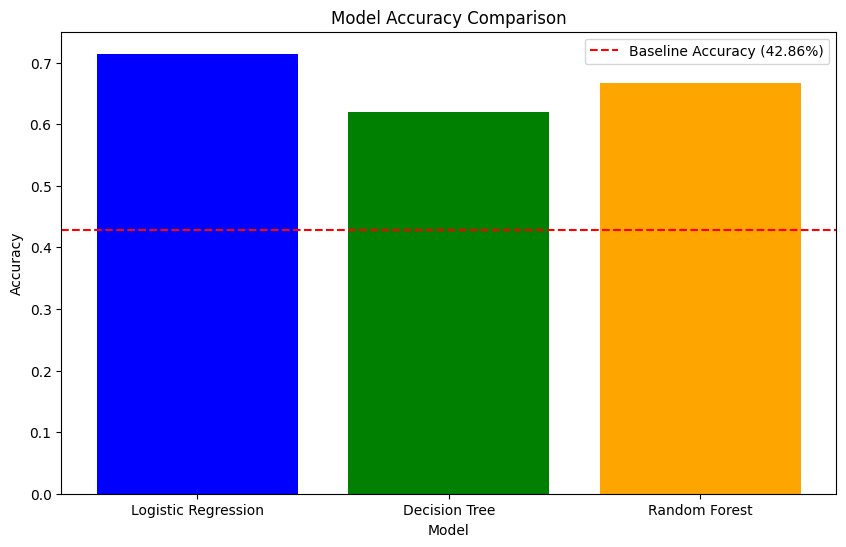

In [53]:
plt.figure(figsize=(10,6))
plt.bar(['Logistic Regression', 'Decision Tree', 'Random Forest'], [accuracy_score(Y_test,Y_pred), accuracy_score(Y_test,Y_dt_pred), accuracy_score(Y_test,Y_rf_pred)], color=['blue', 'green', 'orange'])
plt.ylabel('Accuracy')
plt.xlabel('Model')
plt.title('Model Accuracy Comparison')
plt.axhline(y=baseline_acc, color='red', linestyle='--', label=f'Baseline Accuracy ({baseline_acc*100:.2f}%)')
plt.legend()
plt.show()

Logistic Regression model has the highest accuracy of 71%

In [54]:
import plotly.graph_objects as go

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Baseline Gap']

lr_scores  = [0.71, 0.72, 0.74, 0.70, 0.23]
dt_scores  = [0.62, 0.75, 0.63, 0.64, 0.14]
rf_scores  = [0.67, 0.64, 0.64, 0.63, 0.19]

fig = go.Figure()

fig.add_trace(go.Scatterpolar(
    r=lr_scores + [lr_scores[0]],
    theta=metrics + [metrics[0]],
    fill='toself',
    name='Logistic Regression',
    line_color='royalblue'
))

fig.add_trace(go.Scatterpolar(
    r=dt_scores + [dt_scores[0]],
    theta=metrics + [metrics[0]],
    fill='toself',
    name='Decision Tree',
    line_color='darkorange',
    opacity=0.7
))

fig.add_trace(go.Scatterpolar(
    r=rf_scores + [rf_scores[0]],
    theta=metrics + [metrics[0]],
    fill='toself',
    name='Random Forest',
    line_color='green',
    opacity=0.7
))

fig.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0, 1])),
    title='Model Comparison — Radar Chart',
    showlegend=True
)

fig.show()

In [55]:
import joblib
joblib.dump(model, 'best_model.pkl')
joblib.dump(list(X.columns), 'feature_columns.pkl')

['feature_columns.pkl']